In [1]:
# Importing the requred libraries
import pandas as pd
import seaborn as sns
import joblib
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve, precision_score, recall_score, make_scorer, fbeta_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Loading in my credit risk data
df = pd.read_csv('../data/credit_risk_data.csv')

# Reviewing the first 5 rows of my data
df.head()

,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,<0,6,critical/other existing credit,radio/tv,1169.0,no known savings,>=7,4,male single,none,...,real estate,67,none,own,2,skilled,1,yes,yes,good
1,0<=X<200,48,existing paid,radio/tv,5951.0,<100,1<=X<4,2,female div/dep/mar,none,...,real estate,22,none,own,1,skilled,1,none,yes,bad
2,no checking,12,critical/other existing credit,education,2096.0,<100,4<=X<7,2,male single,none,...,real estate,49,none,own,1,unskilled resident,2,none,yes,good
3,<0,42,existing paid,furniture/equipment,7882.0,<100,4<=X<7,2,male single,guarantor,...,life insurance,45,none,for free,1,skilled,2,none,yes,good
4,<0,24,delayed previously,new car,4870.0,<100,1<=X<4,3,male single,none,...,no known property,53,none,for free,2,skilled,2,none,yes,bad


In [3]:
# Gettinf an overview of my data
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   checking_status         1000 non-null   str    
 1   duration                1000 non-null   int64  
 2   credit_history          1000 non-null   str    
 3   purpose                 1000 non-null   str    
 4   credit_amount           1000 non-null   float64
 5   savings_status          1000 non-null   str    
 6   employment              1000 non-null   str    
 7   installment_commitment  1000 non-null   int64  
 8   personal_status         1000 non-null   str    
 9   other_parties           1000 non-null   str    
 10  residence_since         1000 non-null   int64  
 11  property_magnitude      1000 non-null   str    
 12  age                     1000 non-null   int64  
 13  other_payment_plans     1000 non-null   str    
 14  housing                 1000 non-null   str    
 15 

In [4]:
# From the overview we can see that we have no missing values and most os the columns are strings.
# So we can build a logistic regression model, Decsion Tree and random forest, and decision tree , each requiring different preprocessing steps,
# we will then compare the 3 then pick one that we'll expose as the api based on there performance. 

In [5]:
# Getting the summary statistics for the categorical columns only to check their distribution
df.describe()

,duration,credit_amount,installment_commitment,residence_since,age,existing_credits,num_dependents
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000


In [6]:
# From the desccriptive statistics we can see that the data distribution varies like for example, the min value for duration is 4 
# and the max is 72, while for credit amount, the min is 250 and max is 18424, than means that scaling will be required for the Logistic regression model.  

In [7]:
# Checking for category distribution in categorical columns
categorical_cols = df.select_dtypes(include=['object'])
for column in categorical_cols:
    print(f"Column: \n{column}")
    print(categorical_cols[column].value_counts())


Column: 
checking_status
checking_status
no checking    394
<0             274
0<=X<200       269
>=200           63
Name: count, dtype: int64
Column: 
credit_history
credit_history
existing paid                     530
critical/other existing credit    293
delayed previously                 88
all paid                           49
no credits/all paid                40
Name: count, dtype: int64
Column: 
purpose
purpose
radio/tv               280
new car                234
furniture/equipment    181
used car               103
business                97
education               50
repairs                 22
domestic appliance      12
other                   12
retraining               9
Name: count, dtype: int64
Column: 
savings_status
savings_status
<100                603
no known savings    183
100<=X<500          103
500<=X<1000          63
>=1000               48
Name: count, dtype: int64
Column: 
employment
employment
1<=X<4        339
>=7           253
4<=X<7        174
<1         

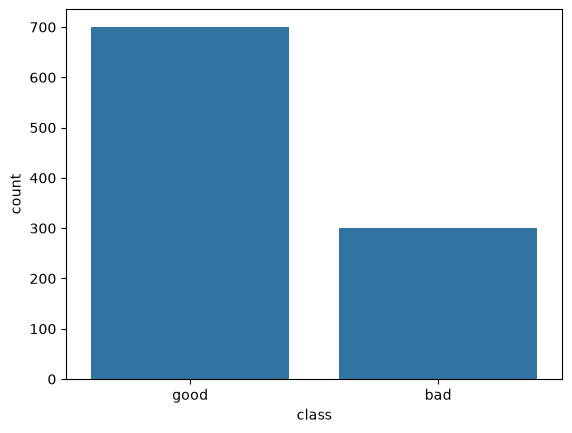

In [8]:
# Visualizing class distribution
sns.countplot(x ='class', data= df)
plt.show()

In [9]:
# For the target varible class lets check the distribution ratio and the class counts 

df['class'].value_counts()
df_minority_class = df[df['class']=='bad']
df_majority_class = df[df['class']=='good']
print(f'Target dirtibution ratio: \n {len(df_minority_class)/ len(df_majority_class)}: 1')

# Manually label encoding my target variable class, the possitve class is 'bad'
df['class'] = df['class'].map({
    'good': 0,
    'bad': 1
})

# Printing the new class distribution
df['class'].value_counts()

Target dirtibution ratio: 
 0.42857142857142855: 1


class
0    700
1    300
Name: count, dtype: int64

In [10]:
# The ratio is 0.42857142857142855: 1, which not that severe so we will just use stratification when spliting to ensure we get the same class distribution in the test and train sets.

In [11]:
# Now I will check correlation between the numerical columns to check if there is any multicollinearity between them, which might affect individual learned coefficients in 
# logistic regression(doesnt affect predictions). 
numerical_cols = df.select_dtypes(include=['int64', 'float64'])
numerical_cols.corr()

,duration,credit_amount,installment_commitment,residence_since,age,existing_credits,num_dependents,class
duration,1.000000,0.624984,0.074749,0.034067,-0.036136,-0.011284,-0.023834,0.214927
credit_amount,0.624984,1.000000,-0.271316,0.028926,0.032716,0.020795,0.017142,0.154739
installment_commitment,0.074749,-0.271316,1.000000,0.049302,0.058266,0.021669,-0.071207,0.072404
residence_since,0.034067,0.028926,0.049302,1.000000,0.266419,0.089625,0.042643,0.002967
age,-0.036136,0.032716,0.058266,0.266419,1.000000,0.149254,0.118201,-0.091127
existing_credits,-0.011284,0.020795,0.021669,0.089625,0.149254,1.000000,0.109667,-0.045732
num_dependents,-0.023834,0.017142,-0.071207,0.042643,0.118201,0.109667,1.000000,-0.003015
class,0.214927,0.154739,0.072404,0.002967,-0.091127,-0.045732,-0.003015,1.000000


In [12]:
# There's no severe correlation between these numerical columns, so I proceed to the next step, which is defining the  target variable and the feature, then splitting my data test and train sets.
X = df.drop(columns='class') 
y = df['class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Train shape: \n {X_train.shape}')
print(f'Test shape: \n {X_test.shape}')

Train shape: 
 (800, 20)
Test shape: 
 (200, 20)


In [13]:
# Training the logistic regression.For all the models we will be using cross validation, stratified k-fold cross-validation, to get a better estimate of the model performance and avoid overfitting and also because my datatset is medium sized 

In [14]:
# Creating a pipeline for logistic regression model, first ww'll performormn column trainformation first
num_cols = X_train.select_dtypes(include=['int64','float64']).columns
cat_cols = X_train.select_dtypes(include=['object']).columns
# 1. The transformer
column_trans = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
]) 
# 2. TThe stratified k-fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# 3. The pipeline
pipeline = Pipeline([
    ('transformer', column_trans),
    ('classifier', LogisticRegression())
])
# 4. cross validation
#cv_score = cross_val_score(pipeline, X_train, y_train, cv=skf, scoring='recall')
#print(f'Cross Validation recall scores: \n {cv_score}')

# 4. fitting one model 
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('transformer', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](20,)","['checking_status','duration','credit_history',...,'num_dependents', 'own_telephone','foreign_worker']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,20
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifyin

In [15]:
# Evaluating my model on the test set
#1. Making predictions
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1] # This uses the default thereshold of 0.5 to classify the positive class.

#2. Evaluating model performance
print(f'Confusion Matrix: \n{confusion_matrix(y_test, y_pred)}')
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
print(f'True Negatives: {tn}, False Positives: {fp}, False Negatives: {fn}, True Positives: {tp}')
print(f"Classification Report: \n{classification_report(y_test, y_pred, target_names=['good', 'bad'])} ")

Confusion Matrix: 
[[124  16]
 [ 28  32]]
True Negatives: 124, False Positives: 16, False Negatives: 28, True Positives: 32
Classification Report: 
              precision    recall  f1-score   support

        good       0.82      0.89      0.85       140
         bad       0.67      0.53      0.59        60

    accuracy                           0.78       200
   macro avg       0.74      0.71      0.72       200
weighted avg       0.77      0.78      0.77       200
 


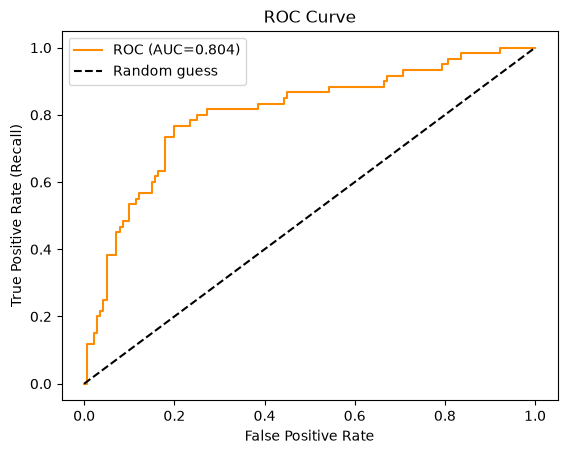

In [16]:
# Out of 60 cases our model can predict 32 true positive cases, and 28 False negatitves at threshold of 0.5.

# Visualizing the Roc-curve, the class imbalance is not that severe, otherwise I'd have used pr-curve

fpr, tpr, thresholds = roc_curve(y_test, y_proba)

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, color='darkorange', label=f'ROC (AUC={roc_auc_score(y_test,y_proba):.3f})')
plt.plot([0,1],[0,1],'k--', label='Random guess')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve'); plt.legend()
plt.show()

In [17]:
# Threshold tuning
print(f"{'Threshold':10s} {'Recall':8s} {'Precision':10s} {'False Negatives':16s} {'False Positives':16s}")
thresholds = [0.5, 0.4, 0.3, 0.2, 0.1]
for threshold in thresholds:
    y_pred_threshold = (y_proba >= threshold).astype(int)
    cm = confusion_matrix(y_test,y_pred_threshold)
    tn, fp, fn, tp = cm.ravel()
    print(f"{threshold:<10} {recall_score(y_test,y_pred_threshold):<8.4f} {precision_score(y_test,y_pred_threshold):<10.4f} {fn:<16d} {fp:<16d}")


Threshold  Recall   Precision  False Negatives  False Positives 
0.5        0.5333   0.6667     28               16              
0.4        0.7167   0.6324     17               25              
0.3        0.8167   0.5632     11               38              
0.2        0.8333   0.4587     10               59              
0.1        0.9000   0.3649     6                94              


In [18]:
# Training a decision tree classifier that will act as a baseline model
# defining a pipeline to be used for tree-based models
tree_prep = ColumnTransformer([
    ('num', 'passthrough', num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

# 3. The pipeline
pipeline2 = Pipeline([
    ('transformer', tree_prep),
    ('classifier', DecisionTreeClassifier(criterion='gini',max_depth=None,min_samples_split=2,min_samples_leaf=1,class_weight=None,random_state=42))

])

# 4. fitting one model 
pipeline2.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('transformer', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](20,)","['checking_status','duration','credit_history',...,'num_dependents', 'own_telephone','foreign_worker']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,20
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifyin

In [19]:
y_pred_dt = pipeline2.predict(X_test)
y_proba_dt = pipeline2.predict_proba(X_test)[:, 1]
#2. Evaluating model performance
print(f'Confusion Matrix: \n{confusion_matrix(y_test, y_pred_dt)}')
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_dt).ravel()
print(f'True Negatives: {tn}, False Positives: {fp}, False Negatives: {fn}, True Positives: {tp}')
print(f"Classification Report: \n{classification_report(y_test, y_pred_dt, target_names=['good', 'bad'])} ")

Confusion Matrix: 
[[101  39]
 [ 37  23]]
True Negatives: 101, False Positives: 39, False Negatives: 37, True Positives: 23
Classification Report: 
              precision    recall  f1-score   support

        good       0.73      0.72      0.73       140
         bad       0.37      0.38      0.38        60

    accuracy                           0.62       200
   macro avg       0.55      0.55      0.55       200
weighted avg       0.62      0.62      0.62       200
 


In [20]:
# 1. Create the pipeline for tuning
pipeline_dt = Pipeline([
    ('transformer', tree_prep),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

# 3. Define the hyperparameter grid
# Use classifier__ because the DT is inside the pipeline
param_grid_dt = {
    'classifier__max_depth': [3, 4, 5, 6, 8, None],
    'classifier__min_samples_split': [2, 5, 10, 20],
    'classifier__min_samples_leaf': [1, 3, 5, 10],
    'classifier__criterion': ['gini', 'entropy'],
    'classifier__class_weight': [None, 'balanced']
}

# 4. Define the F2 scorer
f2_scorer = make_scorer(
    fbeta_score,
    beta=2
)

# 5. Initialize GridSearchCV
grid_dt = GridSearchCV(
    estimator=pipeline_dt,
    param_grid=param_grid_dt,
    scoring=f2_scorer,
    cv=skf,
    n_jobs=-1,
    refit=True,
    verbose=1
)

# 6. Fit the grid search
grid_dt.fit(X_train, y_train)

Fitting 5 folds for each of 384 candidates, totalling 1920 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__class_weight': [None, 'balanced'], 'classifier__criterion': ['gini', 'entropy'], 'classifier__max_depth': [3, 4, ...], 'classifier__min_samples_leaf': [1, 3, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","make_scorer(f...dict', beta=2)"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this 

In [21]:
# Get the best tuned pipeline
best_dt = grid_dt.best_estimator_

# Best hyperparameters
print("Best Parameters:", grid_dt.best_params_)

# Best mean cross-validation F2-score
print("Best CV F2-score:", grid_dt.best_score_)

Best Parameters: {'classifier__class_weight': 'balanced', 'classifier__criterion': 'entropy', 'classifier__max_depth': 3, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2}
Best CV F2-score: 0.7023973412369175


In [22]:
# Now fitting the dt models with the best hyperparameters
pipeline_dt = Pipeline([
    ('transformer', tree_prep),
    ('classifier', DecisionTreeClassifier(class_weight='balanced', criterion='entropy', max_depth=3, min_samples_split=2, min_samples_leaf=1, random_state=42))
])
pipeline_dt.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('transformer', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](20,)","['checking_status','duration','credit_history',...,'num_dependents', 'own_telephone','foreign_worker']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,20
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifyin

In [23]:
y_pred_dt = pipeline_dt.predict(X_test)
y_proba_dt = pipeline_dt.predict_proba(X_test)[:, 1]
# Evaluating model performance
print(f'Confusion Matrix: \n{confusion_matrix(y_test, y_pred_dt)}')
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_dt).ravel()
print(f'True Negatives: {tn}, False Positives: {fp}, False Negatives: {fn}, True Positives: {tp}')
print(f"Classification Report: \n{classification_report(y_test, y_pred_dt, target_names=['good', 'bad'])} ")

Confusion Matrix: 
[[69 71]
 [ 8 52]]
True Negatives: 69, False Positives: 71, False Negatives: 8, True Positives: 52
Classification Report: 
              precision    recall  f1-score   support

        good       0.90      0.49      0.64       140
         bad       0.42      0.87      0.57        60

    accuracy                           0.60       200
   macro avg       0.66      0.68      0.60       200
weighted avg       0.75      0.60      0.62       200
 


In [24]:
# Threshold tuning( lowing the threshold will catch more missed 'bad', but it will also increase the false negatives)
print(f"{'Threshold':10s} {'Recall':8s} {'Precision':10s} {'False Negatives':16s} {'False Positives':16s}")
thresholds = [0.5, 0.4, 0.3, 0.2, 0.1]
for threshold in thresholds:
    y_pred_threshold = (y_proba_dt >= threshold).astype(int)
    cm = confusion_matrix(y_test,y_pred_threshold)
    tn, fp, fn, tp = cm.ravel()
    print(f"{threshold:<10} {recall_score(y_test,y_pred_threshold):<8.4f} {precision_score(y_test,y_pred_threshold):<10.4f} {fn:<16d} {fp:<16d}")

Threshold  Recall   Precision  False Negatives  False Positives 
0.5        0.8667   0.4228     8                71              
0.4        0.8667   0.3939     8                80              
0.3        0.8667   0.3939     8                80              
0.2        0.8667   0.3939     8                80              
0.1        0.9500   0.3032     3                131             


In [25]:
# The baseline rf model

pipeline_rf = Pipeline([
    ('transformer', tree_prep),
    ('classifier',RandomForestClassifier(n_estimators=100,criterion='gini',max_depth=None,min_samples_split=2,min_samples_leaf=1,max_features='sqrt',bootstrap=True,oob_score=True,class_weight=None,random_state=42,n_jobs=-1))

])

# 4. fitting one model 
pipeline_rf.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('transformer', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](20,)","['checking_status','duration','credit_history',...,'num_dependents', 'own_telephone','foreign_worker']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,20
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifyin

In [26]:
# Evaluating the baseline random forest
y_pred_rf = pipeline_rf.predict(X_test)
y_proba_rf = pipeline_rf.predict_proba(X_test)[:, 1]
# Evaluating the random forest model performance
print(f'Confusion Matrix: \n{confusion_matrix(y_test, y_pred_rf)}')
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_rf).ravel()
print(f'True Negatives: {tn}, False Positives: {fp}, False Negatives: {fn}, True Positives: {tp}')
print(f"Classification Report: \n{classification_report(y_test, y_pred_rf, target_names=['good', 'bad'])} ")

Confusion Matrix: 
[[127  13]
 [ 36  24]]
True Negatives: 127, False Positives: 13, False Negatives: 36, True Positives: 24
Classification Report: 
              precision    recall  f1-score   support

        good       0.78      0.91      0.84       140
         bad       0.65      0.40      0.49        60

    accuracy                           0.76       200
   macro avg       0.71      0.65      0.67       200
weighted avg       0.74      0.76      0.74       200
 


In [27]:
from scipy.stats import randint

pipeline_rf = Pipeline([
    ('transformer', tree_prep),
    ('classifier', RandomForestClassifier(
        random_state=42,
        n_jobs=1
    ))
])

# 3. Hyperparameter search space
param_dist_rf = {
    'classifier__n_estimators': randint(100, 601),
    'classifier__max_depth': [None, 5, 10, 15, 20, 30],
    'classifier__min_samples_split': randint(2, 21),
    'classifier__min_samples_leaf': randint(1, 11),
    'classifier__max_features': ['sqrt', 'log2', 0.5, None],
    'classifier__class_weight': [None, 'balanced', 'balanced_subsample']
}

# 4. F2 scorer
f2_scorer = make_scorer(
    fbeta_score,
    beta=2
)

# 5. RandomizedSearchCV
random_rf = RandomizedSearchCV(
    estimator=pipeline_rf,
    param_distributions=param_dist_rf,
    n_iter=50,
    scoring=f2_scorer,
    cv=skf,
    n_jobs=-1,
    refit=True,
    random_state=42,
    verbose=1
)

# 6. Fit
random_rf.fit(X_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'classifier__class_weight': [None, 'balanced', ...], 'classifier__max_depth': [None, 5, ...], 'classifier__max_features': ['sqrt', 'log2', ...], 'classifier__min_samples_leaf': <scipy.stats....002A4A98CDB90>, ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.","make_scorer(f...dict', beta=2)"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at t

In [28]:
# Best tuned pipeline
best_rf = random_rf.best_estimator_

# Best hyperparameters
print("Best Parameters:", random_rf.best_params_)

# Best mean CV F2-score
print("Best CV F2-score:", random_rf.best_score_)

Best Parameters: {'classifier__class_weight': 'balanced', 'classifier__max_depth': 5, 'classifier__max_features': None, 'classifier__min_samples_leaf': 5, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 559}
Best CV F2-score: 0.6884352431701408


In [29]:
feature_names = best_rf.named_steps['transformer'].get_feature_names_out()
importances = best_rf.named_steps['classifier'].feature_importances_

for name, imp in sorted(zip(feature_names, importances), key=lambda x: -x[1]):
    print(f"{name:40s} {imp:.4f}")

cat__checking_status_no checking         0.2995
num__duration                            0.1258
num__credit_amount                       0.1154
num__age                                 0.0469
cat__other_payment_plans_bank            0.0352
cat__savings_status_<100                 0.0284
cat__property_magnitude_real estate      0.0274
cat__other_payment_plans_none            0.0259
num__installment_commitment              0.0251
cat__savings_status_no known savings     0.0234
cat__credit_history_critical/other existing credit 0.0186
cat__credit_history_delayed previously   0.0167
cat__employment_<1                       0.0161
cat__personal_status_male single         0.0118
num__residence_since                     0.0110
cat__property_magnitude_no known property 0.0109
cat__other_parties_none                  0.0097
cat__checking_status_<0                  0.0085
cat__purpose_education                   0.0083
cat__employment_4<=X<7                   0.0079
cat__housing_own             

In [30]:
# Now fitting the rf with tuned hyperparameters
pipeline_rf = Pipeline([
    ('transformer', tree_prep),
    ('classifier',RandomForestClassifier(n_estimators=559, max_depth=5, min_samples_split=2, min_samples_leaf=5, max_features=None, bootstrap=True, oob_score=True, class_weight='balanced', random_state=42, n_jobs=-1))

])

# 4. fitting one model 
pipeline_rf.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('transformer', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](20,)","['checking_status','duration','credit_history',...,'num_dependents', 'own_telephone','foreign_worker']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,20
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifyin

In [31]:
y_pred_rf = pipeline_rf.predict(X_test)
y_proba_rf = pipeline_rf.predict_proba(X_test)[:, 1]
# Evaluating model performance
print(f'Confusion Matrix: \n{confusion_matrix(y_test, y_pred_rf)}')
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_rf).ravel()
print(f'True Negatives: {tn}, False Positives: {fp}, False Negatives: {fn}, True Positives: {tp}')
print(f"Classification Report: \n{classification_report(y_test, y_pred_rf, target_names=['good', 'bad'])} ")

Confusion Matrix: 
[[90 50]
 [17 43]]
True Negatives: 90, False Positives: 50, False Negatives: 17, True Positives: 43
Classification Report: 
              precision    recall  f1-score   support

        good       0.84      0.64      0.73       140
         bad       0.46      0.72      0.56        60

    accuracy                           0.67       200
   macro avg       0.65      0.68      0.65       200
weighted avg       0.73      0.67      0.68       200
 


In [32]:
# Threshold tuning( lowing the threshold will catch more missed 'bad', but it will also increase the false negatives)
print(f"{'Threshold':10s} {'Recall':8s} {'Precision':10s} {'False Negatives':16s} {'False Positives':16s}")
thresholds = [0.5, 0.4, 0.3, 0.2, 0.1]
for threshold in thresholds:
    y_pred_threshold = (y_proba_rf >= threshold).astype(int)
    cm = confusion_matrix(y_test,y_pred_threshold)
    tn, fp, fn, tp = cm.ravel()
    print(f"{threshold:<10} {recall_score(y_test,y_pred_threshold):<8.4f} {precision_score(y_test,y_pred_threshold):<10.4f} {fn:<16d} {fp:<16d}")


Threshold  Recall   Precision  False Negatives  False Positives 
0.5        0.7167   0.4624     17               50              
0.4        0.8333   0.4348     10               65              
0.3        0.9000   0.4060     6                79              
0.2        0.9667   0.3867     2                92              
0.1        0.9833   0.3391     1                115             


In [33]:
# Pick the threshold considering the number of false negatives that your system can handle. in my case i sticking to the default threshold because the number of false negatives is not that high


In [34]:
# since the decision tree is the best performing model, i will save it then expose it as an api using FastAPI
joblib.dump(pipeline_dt, '../models/decision_tree_model.pkl')

['../models/decision_tree_model.pkl']